In [1]:
# import required libraries
import kagglehub
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

In [2]:
# step 01
# If a GPU is listed, Keras will automatically use it during training.
# Check that TensorFlow can see your GPU(s)
gpus = tf.config.list_physical_devices("GPU")
print("GPUs:", gpus)

# (Optional) Enable memory growth so TF doesn’t grab all GPU memory at once
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print("Memory growth enabled for GPUs.")
    except RuntimeError as e:
        print("Memory growth error:", e)
else:
    print("No GPU detected, training will run on CPU.")

GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Memory growth enabled for GPUs.


In [3]:
# step 02
# Download the Apple stock dataset from Kaggle

path = kagglehub.dataset_download("meetnagadia/apple-stock-price-from-19802021")
print("Dataset downloaded to:", path)

Using Colab cache for faster access to the 'apple-stock-price-from-19802021' dataset.
Dataset downloaded to: /kaggle/input/apple-stock-price-from-19802021


In [4]:
# step 03
# load CSV file named "AAPL.csv" that the dataset contain

csv_path = f"{path}/AAPL.csv"
df = pd.read_csv(csv_path)
print(df.head())

         Date      Open      High       Low     Close  Adj Close     Volume
0  1980-12-12  0.128348  0.128906  0.128348  0.128348   0.100178  469033600
1  1980-12-15  0.122210  0.122210  0.121652  0.121652   0.094952  175884800
2  1980-12-16  0.113281  0.113281  0.112723  0.112723   0.087983  105728000
3  1980-12-17  0.115513  0.116071  0.115513  0.115513   0.090160   86441600
4  1980-12-18  0.118862  0.119420  0.118862  0.118862   0.092774   73449600


In [5]:
# step 04
# Prepare univariate time series (Close price)
# normalization

# Ensure data is sorted
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date")

prices = df["Close"].values.astype("float32")

train_size = int(len(prices) * 0.7)
train_prices = prices[:train_size]

mean = train_prices.mean()
std = train_prices.std()
prices_norm = (prices - mean) / std   # normalized level

In [6]:
# step 05
# create supervised sequence

window_size = 60    # lookback
horizon = 1         # 1‑day ahead

def make_sequences(series, window, horizon):
  # series is prices_norm
  # Turn a 1D normalized price series into many (X, y) examples

    X, y = [], []   # X: input windows, y: target changes

    # Slide a window across the series
    for i in range(len(series) - window - horizon):
        # Past 'window' values as input
        X.append(series[i : i + window])              # past levels

        # Future level and last level in the window
        future_level = series[i + window + horizon]   # level at t+1 (look ahead)
        current_level = series[i + window - 1]        # level at t (last in window)

        # Target: future change relative to last value in window
        y.append(future_level - current_level)        # 1‑step change

    # Shape X for RNN: (samples, time_steps, features=1) = (loop range, windowsize, 1(np.newaxis))
    X = np.array(X)[..., np.newaxis]

    # Targets as float32 array
    y = np.array(y).astype("float32")
    return X, y

X, y = make_sequences(prices_norm, window_size, horizon)

# Time‑ordered split: train / val / test
train_frac = 0.7
val_frac   = 0.15
n = len(X)
n_train = int(n * train_frac)
n_val   = int(n * val_frac)

X_train, y_train = X[:n_train], y[:n_train]
X_val,   y_val   = X[n_train:n_train+n_val], y[n_train:n_train+n_val]
X_test,  y_test  = X[n_train+n_val:],        y[n_train+n_val:]

In [7]:
# step 06
# creating tf.data (train_ds, val_ds, test_ds) from X_train, X_val, X_test

batch_size = 64
AUTOTUNE = tf.data.AUTOTUNE

train_ds = (
    tf.data.Dataset.from_tensor_slices((X_train, y_train))
    .batch(batch_size)
    .prefetch(AUTOTUNE)
)

val_ds = (
    tf.data.Dataset.from_tensor_slices((X_val, y_val))
    .batch(batch_size)
    .prefetch(AUTOTUNE)
)

test_ds = (
    tf.data.Dataset.from_tensor_slices((X_test, y_test))
    .batch(batch_size)
    .prefetch(AUTOTUNE)
)

In [8]:
# step 07
# Building the model

inputs = keras.Input(shape=(window_size, 1))

# LSTM learns temporal structure in price sequences
x = layers.LSTM(
    128,
    dropout=0.0,            # dropout on inputs
    recurrent_dropout=0.0,  # dropout on recurrent connections
    )(inputs)

# Dense head with L2 + dropout
x = layers.Dense(
    128,
    activation="relu",
    kernel_regularizer=keras.regularizers.l2(1e-4),
    )(x)
#x = layers.Dropout(0.5)(x)

x = layers.Dense(
    64,
    activation="relu",
    kernel_regularizer=keras.regularizers.l2(1e-4),
    )(x)
#x = layers.Dropout(0.5)(x)

# Regression output: next normalized price
outputs = layers.Dense(1)(x)

lstm_model = keras.Model(inputs, outputs)
lstm_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 60, 1)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 128)            │        66,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 91,393 (357.00 KB)

 Trainable params: 91,393 (357.00 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
# step 08
# compiling the model

lstm_model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss="mse",
    metrics=["mae"],
)

In [10]:
# step 09
# training the model

early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True,
)

history = lstm_model.fit(
    train_ds,
    epochs=100,
    validation_data=val_ds,
    callbacks=[early_stop],
    verbose=2,
)

Epoch 1/100
114/114 - 5s - 41ms/step - loss: 0.0127 - mae: 0.0197 - val_loss: 0.1019 - val_mae: 0.2237
Epoch 2/100
114/114 - 1s - 8ms/step - loss: 0.0043 - mae: 0.0197 - val_loss: 0.1002 - val_mae: 0.2262
Epoch 3/100
114/114 - 1s - 8ms/step - loss: 0.0027 - mae: 0.0186 - val_loss: 0.0983 - val_mae: 0.2233
Epoch 4/100
114/114 - 1s - 7ms/step - loss: 0.0023 - mae: 0.0181 - val_loss: 0.0980 - val_mae: 0.2231
Epoch 5/100
114/114 - 1s - 7ms/step - loss: 0.0021 - mae: 0.0183 - val_loss: 0.0978 - val_mae: 0.2230
Epoch 6/100
114/114 - 1s - 8ms/step - loss: 0.0020 - mae: 0.0183 - val_loss: 0.0978 - val_mae: 0.2230
Epoch 7/100
114/114 - 1s - 7ms/step - loss: 0.0020 - mae: 0.0183 - val_loss: 0.0977 - val_mae: 0.2229
Epoch 8/100
114/114 - 1s - 7ms/step - loss: 0.0020 - mae: 0.0183 - val_loss: 0.0977 - val_mae: 0.2229
Epoch 9/100
114/114 - 1s - 7ms/step - loss: 0.0019 - mae: 0.0183 - val_loss: 0.0977 - val_mae: 0.2229
Epoch 10/100
114/114 - 1s - 11ms/step - loss: 0.0019 - mae: 0.0183 - val_loss: 0.

In [11]:
print("X_test shape:", X_test.shape)   # (N, window, 1)
print("y_test shape:", y_test.shape)   # (N,)

y_pred_norm = lstm_model.predict(X_test).squeeze()  # directly on array
print("y_pred_norm shape:", y_pred_norm.shape)

X_test shape: (1562, 60, 1)
y_test shape: (1562,)
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
y_pred_norm shape: (1562,)


In [12]:
# step 10
# evaluating the model

test_loss, test_mae = lstm_model.evaluate(test_ds, verbose=0)
print("Test MSE:", test_loss)
print("Test MAE (normalized units):", test_mae)

Test MSE: 2.54815936088562
Test MAE (normalized units): 0.9938011169433594


In [13]:
# step 11
# using evaluated model on a example data

# Last window from test set
example_seq = X_test[-1:]                     # shape (1, window_size, 1)

# Model predicts normalized 1‑step change
pred_next = lstm_model.predict(example_seq)[0, 0]

# Last normalized level in that window (current level)
last_level_norm = example_seq[0, -1, 0]

# the true normalized 1‑step change for this window from y_test
true_next = y_test[-1]

# true next normalized price = current level + true change
true_next_norm  = last_level_norm + true_next

# predicted next normalized price = current level + predicted change
pred_next_norm  = last_level_norm + pred_next

# Convert back to original price scale: undo => (price - mean) / std
true_next_price = true_next_norm * std + mean
pred_next_price = pred_next_norm * std + mean

print("True next Close price:", true_next_price)
print("Predicted next Close price:", pred_next_price)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
True next Close price: 131.56
Predicted next Close price: 135.44016


49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


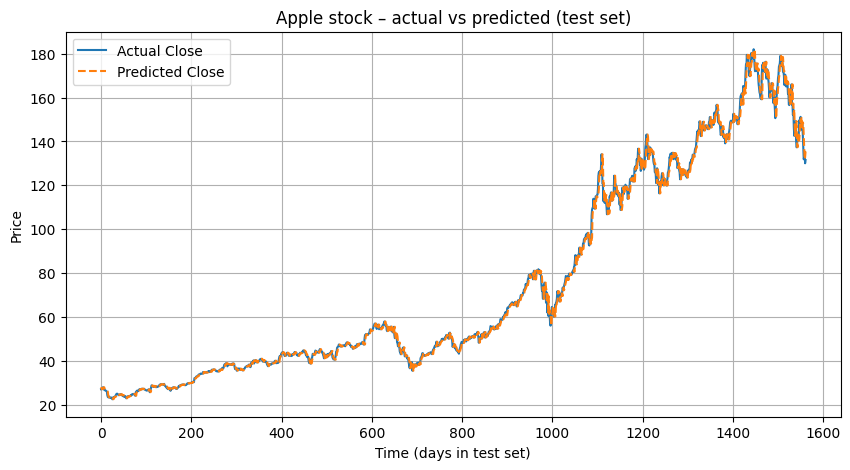

In [14]:
import matplotlib.pyplot as plt

# Predict normalized 1‑step change for all test windows
y_pred = lstm_model.predict(X_test).squeeze()   # shape (len(X_test),)

# Get the last normalized price in each test window (current level)
# X_test: (samples, window_size, 1)
base_levels = X_test[:, -1, 0]                       # shape (len(X_test),)

# Reconstruct predicted next normalized price = current level + predicted change
y_pred_norm = base_levels + y_pred

# Reconstruct true next normalized price = current level + true change
y_true_norm = base_levels + y_test

# Convert both true and predicted prices back to original scale
y_true = y_true_norm * std + mean
y_pred = y_pred_norm * std + mean

plt.figure(figsize=(10, 5))
plt.plot(y_true, label="Actual Close")
plt.plot(y_pred, label="Predicted Close", linestyle="--")
plt.title("Apple stock – actual vs predicted (test set)")
plt.xlabel("Time (days in test set)")
plt.ylabel("Price")
plt.legend()
plt.grid(True)
plt.show()

**Using stacked LSTM Model**

In [15]:
# building the model

# Stacked LSTM model for Apple stock (Close price)

inputs = keras.Input(shape=(window_size, 1))

# First LSTM layer: returns full sequence so the next LSTM can read it
x = layers.LSTM(
    128,
    return_sequences=True,  # IMPORTANT when stacking LSTMs
    )(inputs)

# Second LSTM layer: processes sequence and outputs final hidden state
x = layers.LSTM(
    64,
    return_sequences=False,  # last layer in stack → single vector
    )(x)

# Dense head (no dropout/L2 first, to avoid underfitting)
x = layers.Dense(128, activation="relu")(x)
x = layers.Dense(64, activation="relu")(x)
outputs = layers.Dense(1)(x)  # regression: next normalized Close price

lstm_model = keras.Model(inputs, outputs)
lstm_model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 60, 1)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 60, 128)        │        66,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 132,609 (518.00 KB)

 Trainable params: 132,609 (518.00 KB)

 Non-trainable params: 0 (0.00 B)

In [16]:
# compile the model

lstm_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="mse",
    metrics=["mae"],
)

In [17]:
# step 09
# training the model

early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True,
)

history = lstm_model.fit(
    train_ds,
    epochs=100,
    validation_data=val_ds,
    callbacks=[early_stop],
    verbose=2,
)

Epoch 1/100
114/114 - 4s - 33ms/step - loss: 0.0023 - mae: 0.0216 - val_loss: 0.0978 - val_mae: 0.2222
Epoch 2/100
114/114 - 1s - 11ms/step - loss: 0.0021 - mae: 0.0200 - val_loss: 0.0988 - val_mae: 0.2252
Epoch 3/100
114/114 - 2s - 13ms/step - loss: 0.0022 - mae: 0.0197 - val_loss: 0.0976 - val_mae: 0.2226
Epoch 4/100
114/114 - 1s - 12ms/step - loss: 0.0020 - mae: 0.0190 - val_loss: 0.0976 - val_mae: 0.2222
Epoch 5/100
114/114 - 2s - 16ms/step - loss: 0.0021 - mae: 0.0202 - val_loss: 0.0974 - val_mae: 0.2224
Epoch 6/100
114/114 - 2s - 17ms/step - loss: 0.0019 - mae: 0.0184 - val_loss: 0.0980 - val_mae: 0.2237
Epoch 7/100
114/114 - 1s - 10ms/step - loss: 0.0019 - mae: 0.0180 - val_loss: 0.0981 - val_mae: 0.2239
Epoch 8/100
114/114 - 1s - 10ms/step - loss: 0.0019 - mae: 0.0180 - val_loss: 0.0980 - val_mae: 0.2239
Epoch 9/100
114/114 - 1s - 10ms/step - loss: 0.0019 - mae: 0.0180 - val_loss: 0.0980 - val_mae: 0.2237
Epoch 10/100
114/114 - 1s - 10ms/step - loss: 0.0019 - mae: 0.0179 - val_

In [18]:
print("X_test shape:", X_test.shape)   # (N, window, 1)
print("y_test shape:", y_test.shape)   # (N,)

y_pred_norm = lstm_model.predict(X_test).squeeze()  # directly on array
print("y_pred_norm shape:", y_pred_norm.shape)

X_test shape: (1562, 60, 1)
y_test shape: (1562,)
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step
y_pred_norm shape: (1562,)


In [19]:
# step 10
# evaluating the model

test_loss, test_mae = lstm_model.evaluate(test_ds, verbose=0)
print("Test MSE:", test_loss)
print("Test MAE (normalized units):", test_mae)

Test MSE: 2.5490622520446777
Test MAE (normalized units): 0.9948428273200989


In [20]:
# step 11
# using evaluated model on a example data

# Last window from test set
example_seq = X_test[-1:]                     # shape (1, window_size, 1)

# Model predicts normalized 1‑step change
pred_next = lstm_model.predict(example_seq)[0, 0]

# Last normalized level in that window (current level)
last_level_norm = example_seq[0, -1, 0]

# the true normalized 1‑step change for this window from y_test
true_next = y_test[-1]

# true next normalized price = current level + true change
true_next_norm  = last_level_norm + true_next

# predicted next normalized price = current level + predicted change
pred_next_norm  = last_level_norm + pred_next

# Convert back to original price scale: undo => (price - mean) / std
true_next_price = true_next_norm * std + mean
pred_next_price = pred_next_norm * std + mean

print("True next Close price:", true_next_price)
print("Predicted next Close price:", pred_next_price)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
True next Close price: 131.56
Predicted next Close price: 135.4374


49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


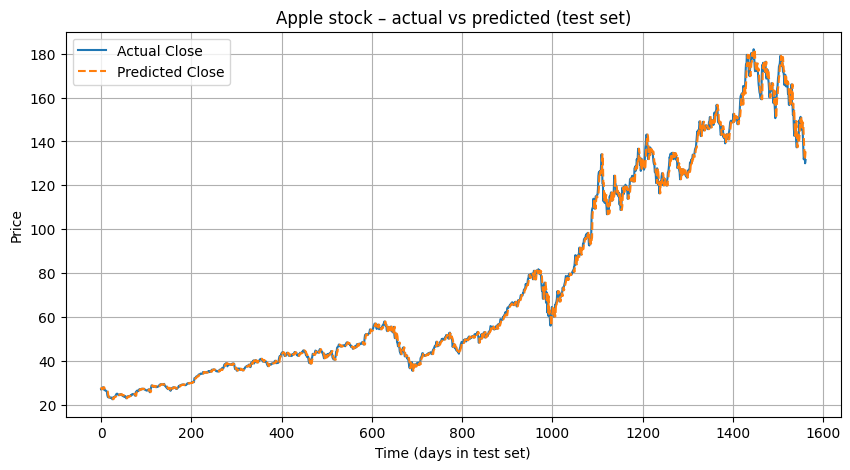

In [21]:
# step 12
# line plot of true and predicted data

import matplotlib.pyplot as plt

# Predict normalized 1‑step change for all test windows
y_pred = lstm_model.predict(X_test).squeeze()   # shape (len(X_test),)

# Get the last normalized price in each test window (current level)
# X_test: (samples, window_size, 1)
base_levels = X_test[:, -1, 0]                       # shape (len(X_test),)

# Reconstruct predicted next normalized price = current level + predicted change
y_pred_norm = base_levels + y_pred

# Reconstruct true next normalized price = current level + true change
y_true_norm = base_levels + y_test

# Convert both true and predicted prices back to original scale
y_true = y_true_norm * std + mean
y_pred = y_pred_norm * std + mean

plt.figure(figsize=(10, 5))
plt.plot(y_true, label="Actual Close")
plt.plot(y_pred, label="Predicted Close", linestyle="--")
plt.title("Apple stock – actual vs predicted (test set)")
plt.xlabel("Time (days in test set)")
plt.ylabel("Price")
plt.legend()
plt.grid(True)
plt.show()